Pricing supplement: https://www.sec.gov/Archives/edgar/data/1665650/000121390025007570/ea0228877-01_424b2.htm

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime
from scipy.interpolate import interp1d

# Dates and Features

In [2]:
trade_date = date(2025, 1, 24)
settlement_date = date(2025, 1, 29)
valuation_date = date(2026, 1, 23)
maturity_date = date(2026, 1, 28)
observation_dates = [date(2025, 4, 23), date(2025, 7, 23), date(2025, 10, 23), date(2026, 1, 23)]
coupon_dates = [date(2025, 4, 28), date(2025, 7, 28), date(2025, 10, 28), date(2026, 1, 28)]

scale = 1
dt = 1 / 365 / scale
N = int((maturity_date - trade_date).days / 365 / dt)

observation_steps = np.array([int((observation_dates[i] - trade_date).days / 365 / dt) for i in range(len(observation_dates))])
coupon_steps = np.array([int((coupon_dates[i] - trade_date).days / 365 / dt) for i in range(len(coupon_dates))])
observation_to_coupon = dict(zip(observation_steps, coupon_steps - observation_steps))

S0 = 190.7
downside_threshold = 123.96
coupon_barrier = 123.96
contingent_coupon = 0.2838
principle = 10

# Parameters of AMAT

In [3]:
# interest rate between trade date and valuation date
discount1 = interp1d([datetime(2025, 10, 24).timestamp(), datetime(2026, 1, 26).timestamp()],
            [0.968590, 0.958622], kind='linear')(datetime(2026, 1, 23).timestamp())
r1 = -np.log(discount1) / ((valuation_date - trade_date).days / 365)
# interest rate between trade date and maturity date
discount2 = interp1d([datetime(2026, 1, 26).timestamp(), datetime(2026, 7, 24).timestamp()],
            [0.958622, 0.939981], kind='linear')(datetime(2026, 1, 28).timestamp())
r2 = -np.log(discount2) / ((maturity_date - trade_date).days / 365)
# volatility vector corresponding to coupon barrier
sigma_vec_barrier = interp1d([datetime(2025, 2, 24).timestamp(), datetime(2025, 4, 24).timestamp(), datetime(2025, 7, 24).timestamp(),
                datetime(2025, 10, 24).timestamp(), datetime(2026, 1, 24).timestamp()],
                [0.66073, 0.46701, 0.42874, 0.41517, 0.41494], kind='linear')
sigma_barrier = sigma_vec_barrier([datetime(2025, 4, 23).timestamp(), datetime(2025, 7, 23).timestamp(),
                  datetime(2025, 10, 23).timestamp(), datetime(2026, 1, 23).timestamp()])
# volatility vector corresponding to at-the-money price
sigma_vec_atm = interp1d([datetime(2025, 2, 24).timestamp(), datetime(2025, 4, 24).timestamp(), datetime(2025, 7, 24).timestamp(),
              datetime(2025, 10, 24).timestamp(), datetime(2026, 1, 24).timestamp()],
              [0.39643, 0.37583, 0.37464, 0.37899, 0.37797], kind='linear')
sigma_atm = sigma_vec_atm([datetime(2025, 4, 23).timestamp(), datetime(2025, 7, 23).timestamp(),
              datetime(2025, 10, 23).timestamp(), datetime(2026, 1, 23).timestamp()])
# dividend yield
delta = 0.01011

# Binomial pricer

In [4]:
def Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma, delta, scale):
  '''
  r1 is the interest rate indicating stock price movement
  r2 is the interest rate indicating time value of money
  sigma is the volatility of stock
  delta is the continuous dividend yield of stock
  '''
  # time step and dates
  dt = 1 / 365 / scale
  N = int((valuation_date - trade_date).days / 365 / dt)

  observation_steps = np.array([int((observation_dates[i] - trade_date).days / 365 / dt) for i in range(len(observation_dates))])
  coupon_steps = np.array([int((coupon_dates[i] - trade_date).days / 365 / dt) for i in range(len(coupon_dates))])
  observation_to_coupon = dict(zip(observation_steps, coupon_steps - observation_steps))

  # calculate tree parameters
  u = np.exp(sigma * np.sqrt(dt))
  d = np.exp(-sigma * np.sqrt(dt))
  q = (np.exp((r1 - delta) * dt) - d) / (u - d)
  disc = np.exp(-r2 * dt)

  # build stock price tree
  S = np.zeros((N + 1, N + 1))
  S[0, 0] = S0
  for i in range(1, N + 1):
    for j in range(i + 1):
      S[i, j] = S0 * u**j * d**(i-j)

  # value the product
  V = np.zeros((N + 1, N + 1))
  for j in range(N + 1): # valuation date
    if S[N, j] >= downside_threshold:
      V[N, j] = (principle + contingent_coupon) * np.exp(-r2 * observation_to_coupon[N] * dt)
    else:
      underlying_return = (S[N, j] - S0) / S0
      V[N, j] = principle * (1 + underlying_return) * np.exp(-r2 * observation_to_coupon[N] * dt)

  for i in range(N - 1, -1, -1):
    for j in range(i + 1):
      if i in observation_steps and S[i, j] >= S0:  # autocall
        V[i, j] = (principle + contingent_coupon) * np.exp(-r2 * observation_to_coupon[i] * dt)
      elif i in observation_steps and S[i, j] >= coupon_barrier:  # contingent coupon
        V[i, j] = disc * (q * V[i + 1, j + 1] + (1 - q) * V[i + 1, j]) + contingent_coupon * np.exp(-r2 * observation_to_coupon[i] * dt)
      else:
        V[i, j] = disc * (q * V[i + 1, j + 1] + (1 - q) * V[i + 1, j])

  return V[0, 0]


# Results

In [6]:
# 9.76 from description
print(f"ATM volatility at maturity = {sigma_atm[-1]} , price = {Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma_atm[-1], delta, 1)}")
print(f"Mean of ATM volatility on observation dates = {sigma_atm.mean()} , price = {Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma_atm.mean(), delta, 1)}")
print(f"coupon barrier volatility at maturity = {sigma_barrier[-1]} , price = {Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma_barrier[-1], delta, 1)}")
print(f"Mean of coupon barrier volatility on observation dates = {sigma_barrier.mean()} , price = {Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma_barrier.mean(), delta, 1)}")

ATM volatility at maturity = 0.3779810869565217 , price = 9.752146451230972
Mean of ATM volatility on observation dates = 0.37693900845331896 , price = 9.754718625172769
coupon barrier volatility at maturity = 0.4149425 , price = 9.608096252709142
Mean of coupon barrier volatility on observation dates = 0.43242848482026447 , price = 9.57501840283312


In [ ]:
value_atm = []
value_avg_atm = []
value_barrier = []
value_avg_barrier = []
for scale in range(1, 11):
  value_atm.append(Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma_atm[-1], delta, scale))
  value_avg_atm.append(Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma_atm.mean(), delta, scale))
  value_barrier.append(Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma_barrier[-1], delta, scale))
  value_avg_barrier.append(Contingent_Coupon_Auto_Callable_Notes_pricer(r1, r2, sigma_barrier.mean(), delta, scale))
  print(scale)

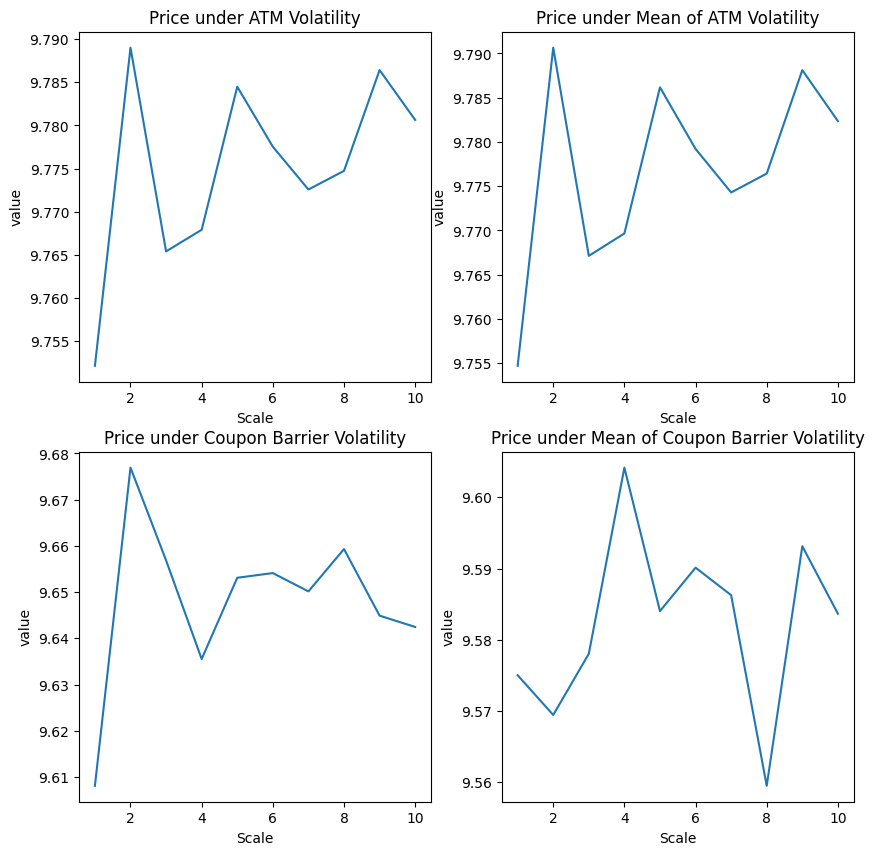

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].plot(range(1, 11), value_atm[:10])
ax[0, 0].set_xlabel('Scale')
ax[0, 0].set_ylabel('value')
ax[0, 0].set_title('Price under ATM Volatility')
ax[0, 1].plot(range(1, 11), value_avg_atm[:10])
ax[0, 1].set_xlabel('Scale')
ax[0, 1].set_ylabel('value')
ax[0, 1].set_title('Price under Mean of ATM Volatility')
ax[1, 0].plot(range(1, 11), value_barrier[:10])
ax[1, 0].set_xlabel('Scale')
ax[1, 0].set_ylabel('value')
ax[1, 0].set_title('Price under Coupon Barrier Volatility')
ax[1, 1].plot(range(1, 11), value_avg_barrier[:10])
ax[1, 1].set_xlabel('Scale')
ax[1, 1].set_ylabel('value')
ax[1, 1].set_title('Price under Mean of Coupon Barrier Volatility')
plt.show()